# t-SNE and UMAP-Style Embedding Comparison

Dimensionality reduction balances neighborhood preservation and global geometry.
We compare PCA, a t-SNE-like neighborhood embedding objective, and a graph-spectral embedding in a didactic pipeline.

Both t-SNE and UMAP-style embeddings prioritize neighborhood structure rather than global Euclidean accuracy. Their objectives encode local affinities differently, so apparent clusters must be read alongside trustworthiness and continuity diagnostics. The comparison emphasizes stability across parameters rather than one attractive layout.

No embedding should be judged from appearance alone. Repeated views and neighborhood scores are used to distinguish reproducible local structure from layout-specific visual separation.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/tsne-umap-comparison/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/tsne-umap-comparison") if Path("python/tsne-umap-comparison").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **t-SNE and UMAP-Style Embedding Comparison**, with equations and plots designed to expose both the model and the numerical behavior.


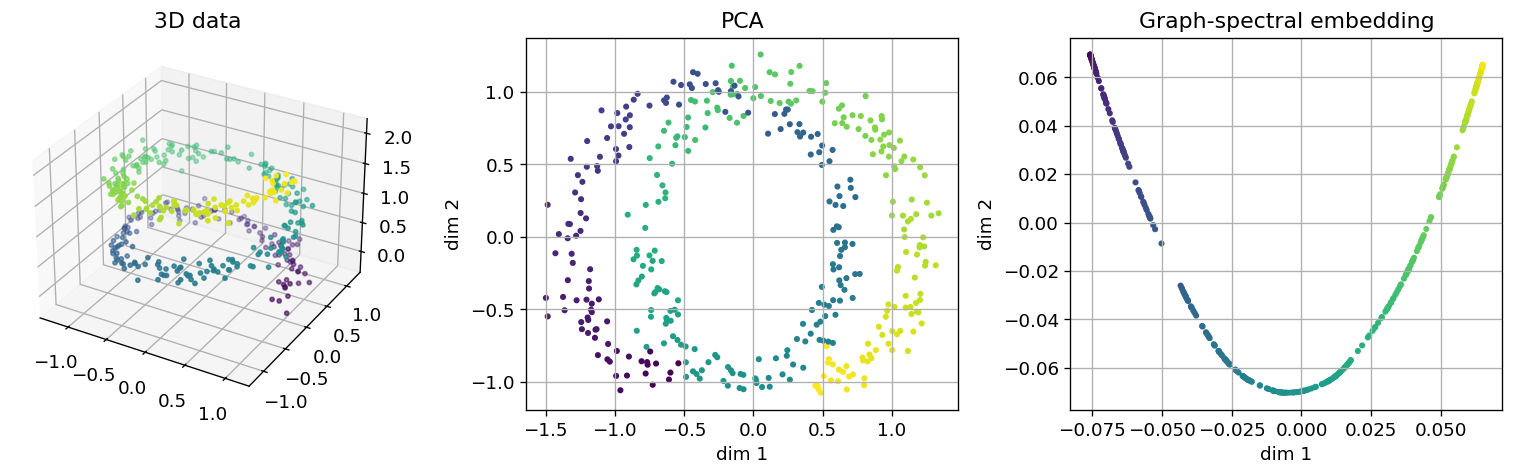

In [2]:
n = 400
t = rng.uniform(0, 4*np.pi, size=n)
X3 = np.c_[np.cos(t), np.sin(t), t/(2*np.pi)] + 0.08*rng.normal(size=(n, 3))

# PCA baseline
Xc = X3 - X3.mean(axis=0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
Xpca = Xc @ Vt[:2].T

# Graph spectral embedding (UMAP-like neighborhood graph perspective)
k = 12
d2 = np.sum((X3[:, None, :] - X3[None, :, :])**2, axis=2)
idx = np.argsort(d2, axis=1)[:, 1:k+1]
W = np.zeros((n, n))
for i in range(n):
    W[i, idx[i]] = np.exp(-d2[i, idx[i]] / 0.12)
W = np.maximum(W, W.T)
D = np.diag(W.sum(axis=1))
L = D - W
evals, evecs = np.linalg.eigh(L)
Xspec = evecs[:, 1:3]

fig = plt.figure(figsize=(13.0, 4.1))
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.scatter(X3[:, 0], X3[:, 1], X3[:, 2], c=t, s=6, cmap="viridis")
ax1.set_title("3D data")
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(Xpca[:, 0], Xpca[:, 1], c=t, s=7, cmap="viridis")
ax2.set_title("PCA")
ax3 = fig.add_subplot(1, 3, 3)
ax3.scatter(Xspec[:, 0], Xspec[:, 1], c=t, s=7, cmap="viridis")
ax3.set_title("Graph-spectral embedding")
for ax in [ax2, ax3]:
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- L. van der Maaten, G. Hinton, "Visualizing Data using t-SNE", JMLR, 2008.
- L. McInnes, J. Healy, J. Melville, "UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction", 2018.
- J. A. Lee, M. Verleysen, *Nonlinear Dimensionality Reduction*, Springer, 2007.
